In [1]:
# Import necessary libraries
import pandas as pd
from pymongo import MongoClient
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import RidgeClassifier
import lightgbm as lgb


# Connect to MongoDB
client = MongoClient("mongodb://localhost:27017/")
db = client["main_db"]

# Fetch the cleaned superdataset from MongoDB
superdataset = pd.DataFrame(list(db["superdataset1"].find()))

In [2]:
# Drop MongoDB's default `_id` column if present
if "_id" in superdataset.columns:
    superdataset = superdataset.drop(columns=["_id"])

In [3]:
# Relevant columns for features and target
features = [
     'Map', 
    'Team_A_ID','Team_A_Kills', 'Team_A_Deaths', 'Team_A_ACS', 'Team_A_Headshot_Percentage', 'Team_A_First_Bloods', 'Team_A_Assists',
    'Team_B_ID', 'Team_B_Kills', 'Team_B_Deaths', 'Team_B_ACS', 'Team_B_Headshot_Percentage', 'Team_B_First_Bloods', 'Team_B_Assists', 
]

target = 'Winner'

In [4]:

X = superdataset[features]
y = superdataset[target]

In [5]:
X

,Map,Team_A_ID,Team_A_Kills,Team_A_Deaths,Team_A_ACS,Team_A_Headshot_Percentage,Team_A_First_Bloods,Team_A_Assists,Team_B_ID,Team_B_Kills,Team_B_Deaths,Team_B_ACS,Team_B_Headshot_Percentage,Team_B_First_Bloods,Team_B_Assists
0,Fracture,474,469.0,276.0,450.769231,31.384615,32.0,234.0,4915,313.0,255.0,368.636364,25.909091,36.0,185.0
1,Lotus,8185,303.0,287.0,292.083333,25.583333,51.0,95.0,6961,471.0,263.0,374.666667,27.733333,47.0,182.0
2,Pearl,1184,667.0,579.0,308.076923,28.807692,138.0,268.0,14,267.0,249.0,300.384615,29.923077,50.0,247.0
3,Ascent,5248,571.0,438.0,386.944444,28.333333,93.0,251.0,11328,529.0,506.0,322.142857,27.952381,103.0,295.0
4,Bind,4915,450.0,418.0,357.352941,24.529412,125.0,315.0,8185,365.0,253.0,410.000000,23.272727,29.0,172.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
759,Icebox,5448,250.0,196.0,300.909091,27.000000,60.0,162.0,6199,344.0,336.0,283.125000,29.562500,64.0,218.0
760,Icebox,17,633.0,441.0,436.388889,29.611111,83.0,305.0,5448,230.0,247.0,254.090909,28.090909,87.0,99.0
761,Split,14,295.0,294.0,340.000000,31.545455,37.0,158.0,624,410.0,317.0,385.769231,28.769231,28.0,183.0
762,Bind,8185,933.0,786.0,333.382353,30.470588,132.0,401.0,17,318.0,271.0,377.727273,35.454545,36.0,195.0


In [6]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical features
categorical_features = ['Map']
label_encoders = {col: LabelEncoder() for col in categorical_features}

for col in categorical_features:
    X[col] = label_encoders[col].fit_transform(X[col])

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24600\3655108482.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = label_encoders[col].fit_transform(X[col])


In [7]:
X

,Map,Team_A_ID,Team_A_Kills,Team_A_Deaths,Team_A_ACS,Team_A_Headshot_Percentage,Team_A_First_Bloods,Team_A_Assists,Team_B_ID,Team_B_Kills,Team_B_Deaths,Team_B_ACS,Team_B_Headshot_Percentage,Team_B_First_Bloods,Team_B_Assists
0,4,474,469.0,276.0,450.769231,31.384615,32.0,234.0,4915,313.0,255.0,368.636364,25.909091,36.0,185.0
1,7,8185,303.0,287.0,292.083333,25.583333,51.0,95.0,6961,471.0,263.0,374.666667,27.733333,47.0,182.0
2,8,1184,667.0,579.0,308.076923,28.807692,138.0,268.0,14,267.0,249.0,300.384615,29.923077,50.0,247.0
3,1,5248,571.0,438.0,386.944444,28.333333,93.0,251.0,11328,529.0,506.0,322.142857,27.952381,103.0,295.0
4,2,4915,450.0,418.0,357.352941,24.529412,125.0,315.0,8185,365.0,253.0,410.000000,23.272727,29.0,172.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
759,6,5448,250.0,196.0,300.909091,27.000000,60.0,162.0,6199,344.0,336.0,283.125000,29.562500,64.0,218.0
760,6,17,633.0,441.0,436.388889,29.611111,83.0,305.0,5448,230.0,247.0,254.090909,28.090909,87.0,99.0
761,9,14,295.0,294.0,340.000000,31.545455,37.0,158.0,624,410.0,317.0,385.769231,28.769231,28.0,183.0
762,2,8185,933.0,786.0,333.382353,30.470588,132.0,401.0,17,318.0,271.0,377.727273,35.454545,36.0,195.0


In [8]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [9]:

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# MODEL PIPELINE

In [10]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    # Print metrics
    print(f"{model_name} Performance:")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"F1-Score: {f1:.2f}")
    print(f"ROC-AUC: {roc_auc:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()
    
    return accuracy, f1, roc_auc, precision, recall

# Initialize the results dictionary to store evaluation metrics
results = {}

XGBoost Performance:
Accuracy: 0.73
F1-Score: 0.73
ROC-AUC: 0.76
Precision: 0.73
Recall: 0.73


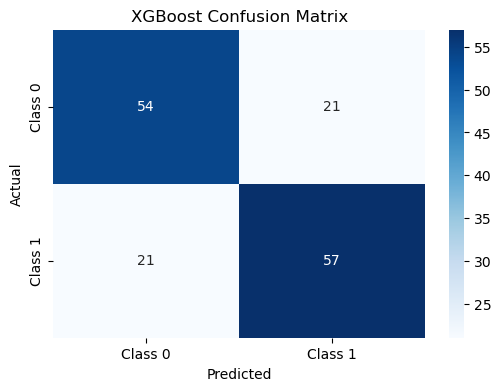

In [11]:

# Convert results to DataFrame
results_df = pd.DataFrame(results, index=['Accuracy', 'F1-Score', 'ROC-AUC', 'Precision', 'Recall'])


# Model 1: XGBoost
xgb_model = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)
results['XGBoost'] = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

Logistic Regression Performance:
Accuracy: 0.66
F1-Score: 0.66
ROC-AUC: 0.71
Precision: 0.68
Recall: 0.64


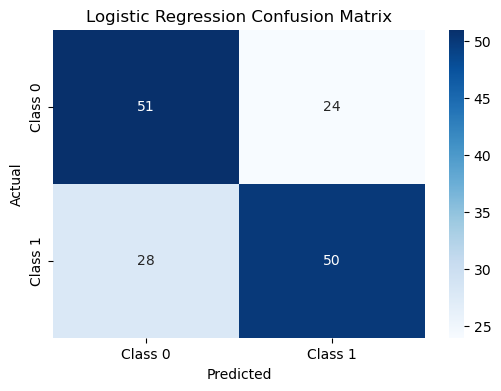

In [12]:
# Model 3: Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(random_state=42, max_iter=100)
lr_model.fit(X_train, y_train)
results['Logistic Regression'] = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")


Naive Bayes Performance:
Accuracy: 0.67
F1-Score: 0.68
ROC-AUC: 0.71
Precision: 0.68
Recall: 0.69


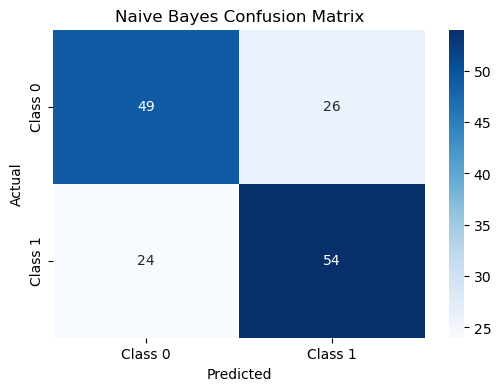

In [14]:
from sklearn.naive_bayes import GaussianNB

# Model 5: Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Evaluate the Naive Bayes model
results['Naive Bayes'] = evaluate_model(nb_model, X_test, y_test, "Naive Bayes")

# Convert results to DataFrame for comparison
results_df = pd.DataFrame(results, index=['Accuracy', 'F1-Score', 'ROC-AUC', 'Precision', 'Recall'])




Decision Tree Performance:
Accuracy: 0.55
F1-Score: 0.55
ROC-AUC: 0.55
Precision: 0.56
Recall: 0.54


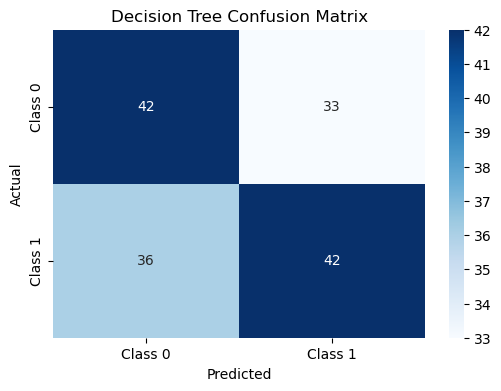

In [15]:
# Model 4: Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
results['Decision Tree'] = evaluate_model(dt_model, X_test, y_test, "Decision Tree")


Gradient Boosting Performance:
Accuracy: 0.71
F1-Score: 0.70
ROC-AUC: 0.75
Precision: 0.73
Recall: 0.68


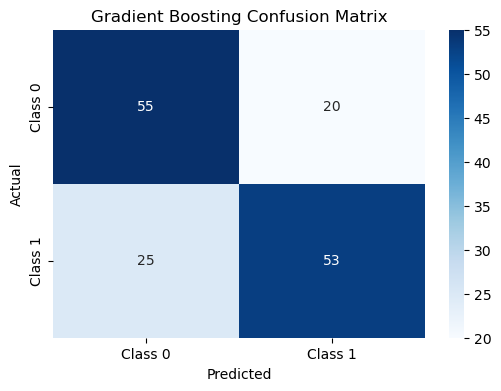

In [16]:
# Model 5: Gradient Boosting (GBM)
gbm_model =  GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gbm_model.fit(X_train, y_train)
results['Gradient Boosting'] = evaluate_model(gbm_model, X_test, y_test, "Gradient Boosting")


AdaBoost Performance:
Accuracy: 0.63
F1-Score: 0.64
ROC-AUC: 0.67
Precision: 0.63
Recall: 0.64


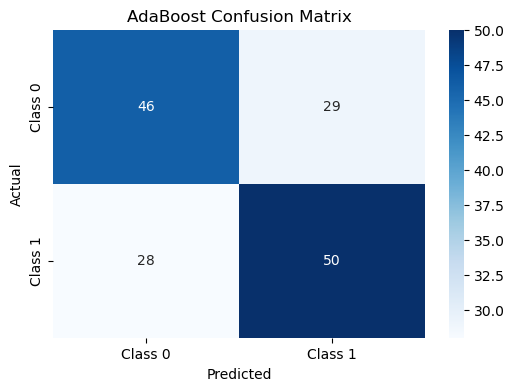

In [17]:

# Model 6: AdaBoost
adaboost_model = AdaBoostClassifier(n_estimators=200, random_state=42)
adaboost_model.fit(X_train, y_train)
results['AdaBoost'] = evaluate_model(adaboost_model, X_test, y_test, "AdaBoost")

SVM Performance:
Accuracy: 0.71
F1-Score: 0.72
ROC-AUC: 0.75
Precision: 0.70
Recall: 0.73


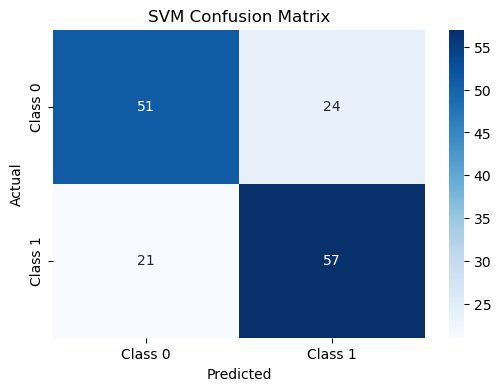

In [18]:
# Model 8: Support Vector Machine (SVM)
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)
results['SVM'] = evaluate_model(svm_model, X_test, y_test, "SVM")

KNN Performance:
Accuracy: 0.62
F1-Score: 0.63
ROC-AUC: 0.66
Precision: 0.62
Recall: 0.64


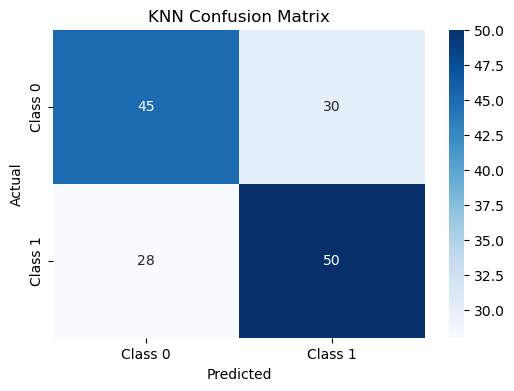

In [19]:
# Model 9: K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
results['KNN'] = evaluate_model(knn_model, X_test, y_test, "KNN")


CatBoost Performance:
Accuracy: 0.72
F1-Score: 0.73
ROC-AUC: 0.76
Precision: 0.72
Recall: 0.73


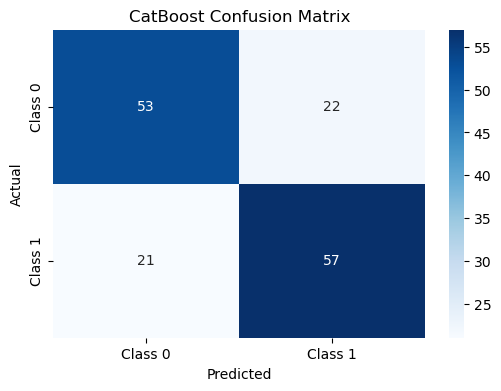

In [20]:
from catboost import CatBoostClassifier


# Model 15: CatBoost
catboost_model = CatBoostClassifier(iterations=200, depth=4, learning_rate=0.05, verbose=0, random_state=42)
catboost_model.fit(X_train, y_train)
results['CatBoost'] = evaluate_model(catboost_model, X_test, y_test, "CatBoost")


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\ensemble\_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


Bagging Performance:
Accuracy: 0.67
F1-Score: 0.69
ROC-AUC: 0.72
Precision: 0.67
Recall: 0.71


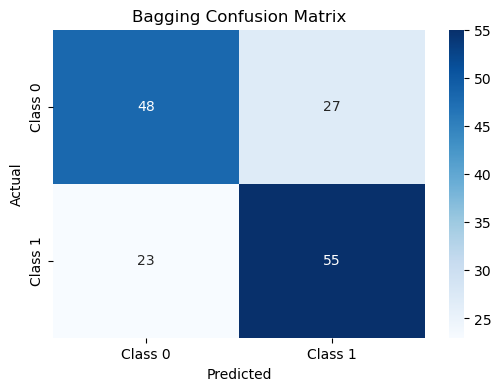

In [22]:
# Model 15: BaggingClassifier
bagging_model = BaggingClassifier(base_estimator=DecisionTreeClassifier(random_state=42), n_estimators=100, random_state=42)
bagging_model.fit(X_train, y_train)
results['Bagging'] = evaluate_model(bagging_model, X_test, y_test, "Bagging")



C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\experimental\enable_hist_gradient_boosting.py:15: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


Histogram-Based Gradient Boosting Performance:
Accuracy: 0.70
F1-Score: 0.71
ROC-AUC: 0.74
Precision: 0.71
Recall: 0.71


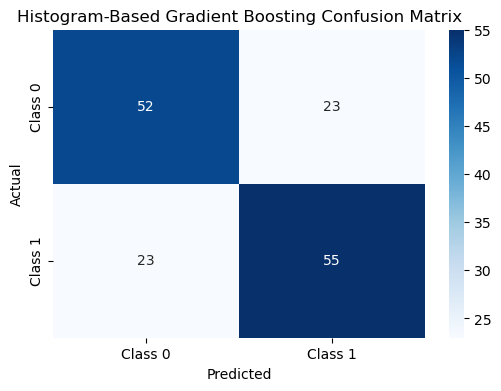

In [23]:
# Model 17: Histogram-Based Gradient Boosting
from sklearn.experimental import enable_hist_gradient_boosting  # noqa
from sklearn.ensemble import HistGradientBoostingClassifier
hgb_model = HistGradientBoostingClassifier(max_iter=100, random_state=42)
hgb_model.fit(X_train, y_train)
results['HGB'] = evaluate_model(hgb_model, X_test, y_test, "Histogram-Based Gradient Boosting")


Epoch 1/50


C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5096 - loss: 0.6943
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5224 - loss: 0.6911 
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5587 - loss: 0.6691 
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5658 - loss: 0.6703 
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5734 - loss: 0.6691 
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6087 - loss: 0.6549 
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6188 - loss: 0.6580 
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6341 - loss: 0.6498 
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6193 - loss: 0.6437 
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6221 - loss: 0.6453 
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6269 - loss: 0.6399 
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6324 - los

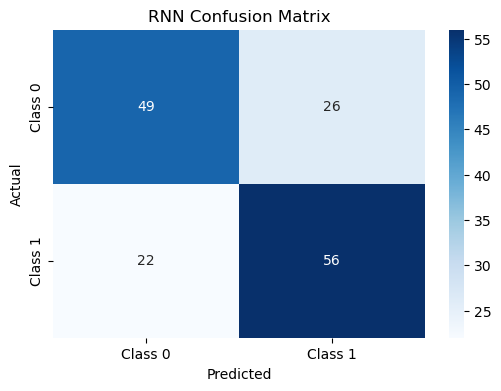

In [24]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Reshape data for RNN
# RNN expects input shape as (samples, timesteps, features)
X_train_rnn = np.expand_dims(X_train, axis=1)  # Adding a "time" dimension
X_test_rnn = np.expand_dims(X_test, axis=1)

# Define RNN Model
rnn_model = Sequential([
    SimpleRNN(128, activation='relu', input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the RNN model
rnn_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the RNN model
rnn_model.fit(X_train_rnn, y_train, epochs=50, batch_size=50, verbose=1)

# Evaluate the RNN model
rnn_loss, rnn_accuracy = rnn_model.evaluate(X_test_rnn, y_test, verbose=0)
y_pred_rnn_proba = rnn_model.predict(X_test_rnn).flatten()
y_pred_rnn = (y_pred_rnn_proba > 0.5).astype(int)

# Evaluate RNN model performance
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_rnn)
f1 = f1_score(y_test, y_pred_rnn)
roc_auc = roc_auc_score(y_test, y_pred_rnn_proba)
precision = precision_score(y_test, y_pred_rnn)
recall = recall_score(y_test, y_pred_rnn)
cm = confusion_matrix(y_test, y_pred_rnn)

# Print metrics
print("RNN Performance:")
print(f"Accuracy: {accuracy:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"ROC-AUC: {roc_auc:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RNN Confusion Matrix")
plt.show()

# Add RNN results to the results dictionary
results['RNN'] = [accuracy, f1, roc_auc, precision, recall]



Model Comparison:
            XGBoost  Logistic Regression  Naive Bayes  Decision Tree  \
Accuracy   0.725490             0.660131     0.673203       0.549020   
F1-Score   0.734177             0.657895     0.683544       0.549020   
ROC-AUC    0.742735             0.708547     0.714701       0.549231   
Precision  0.725000             0.675676     0.675000       0.560000   
Recall     0.743590             0.641026     0.692308       0.538462   

           Gradient Boosting  AdaBoost       SVM       KNN  CatBoost  \
Accuracy            0.705882  0.627451  0.705882  0.620915  0.718954   
F1-Score            0.701987  0.636943  0.716981  0.632911  0.726115   
ROC-AUC             0.747863  0.673333  0.745128  0.656068  0.762735   
Precision           0.726027  0.632911  0.703704  0.625000  0.721519   
Recall              0.679487  0.641026  0.730769  0.641026  0.730769   

            Bagging       HGB       RNN  
Accuracy   0.673203  0.699346  0.686275  
F1-Score   0.687500  0.705128  

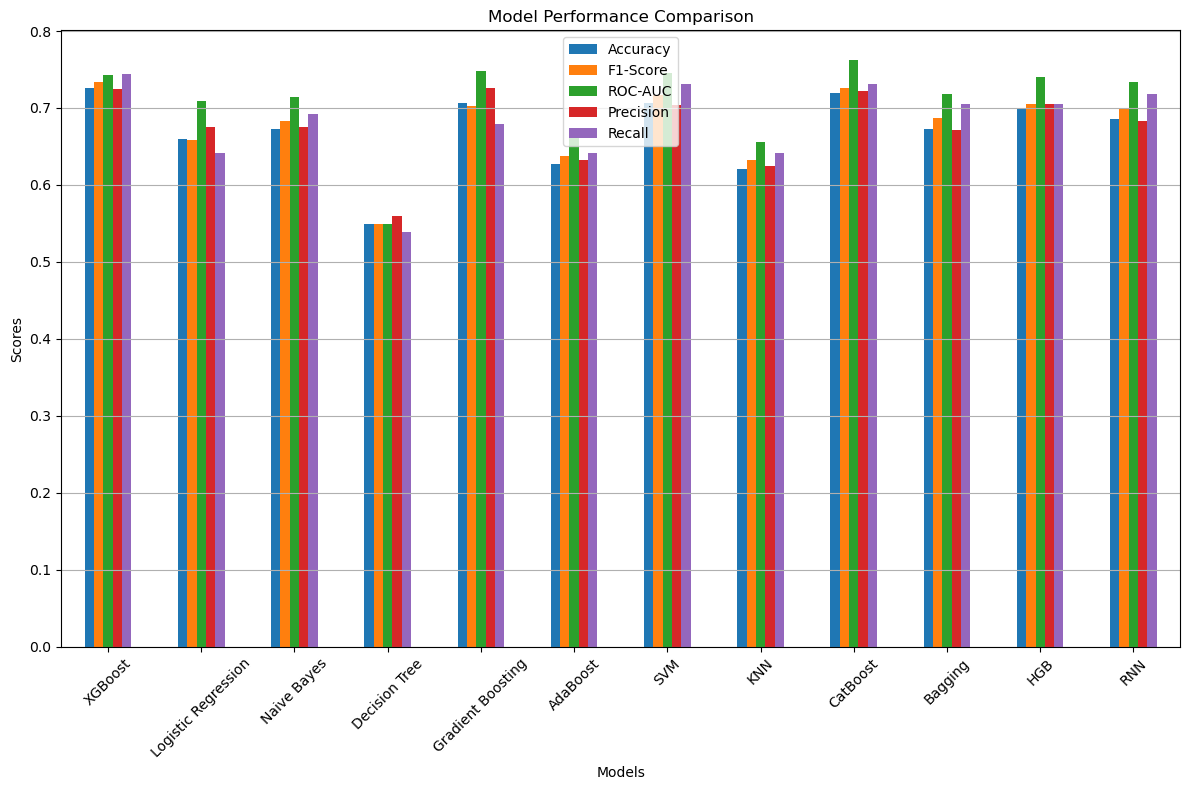

In [25]:
# Convert results to DataFrame
results_df = pd.DataFrame(results, index=['Accuracy', 'F1-Score', 'ROC-AUC', 'Precision', 'Recall'])

# Display results
print("\nModel Comparison:")
print(results_df)

# Plot comparison
results_df.T.plot(kind='bar', figsize=(12, 8))
plt.title("Model Performance Comparison")
plt.ylabel("Scores")
plt.xlabel("Models")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Hybrid Model Performance:
Accuracy: 0.70
F1-Score: 0.72
ROC-AUC: 0.74
Precision: 0.69
Recall: 0.76


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


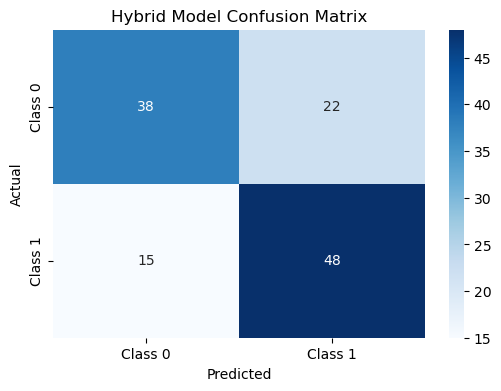

In [27]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

# Define base models
models = {
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(50,), max_iter=300, random_state=42)
}

# Train base models and create meta-features
meta_features = pd.DataFrame()
for name, model in models.items():
    # Using cross-validation predictions to avoid overfitting
    meta_features[name] = cross_val_predict(model, X_train, y_train, cv=5, method='predict_proba')[:,1]

# Meta-model
meta_model = LogisticRegression(random_state=42)

# Split the meta-features for training and testing
meta_X_train, meta_X_test, meta_y_train, meta_y_test = train_test_split(meta_features, y_train, test_size=0.2, random_state=42)

# Train the meta-model
meta_model.fit(meta_X_train, meta_y_train)

# Evaluate the hybrid model
hybrid_y_pred = meta_model.predict(meta_X_test)
hybrid_y_pred_proba = meta_model.predict_proba(meta_X_test)[:, 1]

# Print performance metrics
print("Hybrid Model Performance:")
print(f"Accuracy: {accuracy_score(meta_y_test, hybrid_y_pred):.2f}")
print(f"F1-Score: {f1_score(meta_y_test, hybrid_y_pred):.2f}")
print(f"ROC-AUC: {roc_auc_score(meta_y_test, hybrid_y_pred_proba):.2f}")
print(f"Precision: {precision_score(meta_y_test, hybrid_y_pred):.2f}")
print(f"Recall: {recall_score(meta_y_test, hybrid_y_pred):.2f}")

# Confusion matrix visualization
cm = confusion_matrix(meta_y_test, hybrid_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Hybrid Model Confusion Matrix")
plt.show()


# DEPLOYMENT

In [26]:

# Import necessary libraries
import pandas as pd
from pymongo import MongoClient
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib
import pickle
import io
import bson

# Connect to MongoDB
client = MongoClient("mongodb://localhost:27017/")
db = client["main_db"]

# Fetch the superdataset from MongoDB
superdataset = pd.DataFrame(list(db["superdataset1"].find()))

# Drop MongoDB's default `_id` column if present
if "_id" in superdataset.columns:
    superdataset = superdataset.drop(columns=["_id"])

# Relevant columns for features and target
features = [
    'Map', 
    'Team_A_ID', 'Team_A_Kills', 'Team_A_Deaths', 'Team_A_ACS', 
    'Team_A_Headshot_Percentage', 'Team_A_First_Bloods', 'Team_A_Assists',
    'Team_B_ID', 'Team_B_Kills', 'Team_B_Deaths', 'Team_B_ACS', 
    'Team_B_Headshot_Percentage', 'Team_B_First_Bloods', 'Team_B_Assists'
]
target = 'Winner'

# Split data into features (X) and target (y)
X = superdataset[features]
y = superdataset[target]

# Encode categorical features
label_encoder = LabelEncoder()
X['Map'] = label_encoder.fit_transform(X['Map'])

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the XGBoost model
xgb_model = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)

# Save the XGBoost model to MongoDB
model_buffer = io.BytesIO()
joblib.dump(xgb_model, model_buffer)
model_bson = bson.Binary(model_buffer.getvalue())

# Serialize the label encoder and scaler
label_encoder_bson = bson.Binary(pickle.dumps(label_encoder))
scaler_bson = bson.Binary(pickle.dumps(scaler))

# Insert the XGBoost model, label encoder, and scaler into MongoDB
db["models"].insert_one({
    "model_name": "xgboost",
    "model_data": model_bson,
    "label_encoder": label_encoder_bson,
    "scaler": scaler_bson
})

print("XGBoost model, label encoder, and scaler saved to MongoDB.")



C:\Users\ASUS\AppData\Local\Temp\ipykernel_24600\58575393.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Map'] = label_encoder.fit_transform(X['Map'])


In [28]:


# Retrieve the XGBoost model from MongoDB
model_data = db["models"].find_one({"model_name": "xgboost"})

# Deserialize the XGBoost model
model_buffer = io.BytesIO(model_data["model_data"])
saved_xgb_model = joblib.load(model_buffer)

# Deserialize the label encoder and scaler
label_encoder = pickle.loads(model_data["label_encoder"])
scaler = pickle.loads(model_data["scaler"])

print("XGBoost model, label encoder, and scaler loaded from MongoDB.")


XGBoost model, label encoder, and scaler loaded from MongoDB.


In [29]:



def calculate_odds_and_earnings(prob_a, prob_b, bet_amount, margin=0.05):
    """
    Convert probabilities into realistic bookmaker odds and then calculate potential earnings.
    
    Parameters:
    - prob_a (float): Probability of Team A winning.
    - prob_b (float): Probability of Team B winning.
    - bet_amount (float): Amount of money bet.
    - margin (float): Overround margin the bookmaker adds.
    
    Returns:
    - odds_a (float): Bookmaker odds for Team A.
    - odds_b (float): Bookmaker odds for Team B.
    - earnings_a (float): Potential earnings if you bet on Team A and they win.
    - earnings_b (float): Potential earnings if you bet on Team B and they win.
    """
    # Compute fair odds
    if prob_a <= 0 or prob_b <= 0:
        raise ValueError("Probabilities must be greater than 0.")
    
    fair_odds_a = 1.0 / prob_a
    fair_odds_b = 1.0 / prob_b

    # To apply a margin, we distribute it proportionally.
    # One approach is to adjust each fair odds downward so that
    # the implied probabilities sum to more than 1.
    # Implied probabilities from fair odds:
    implied_a = 1.0 / fair_odds_a
    implied_b = 1.0 / fair_odds_b
    sum_implied = implied_a + implied_b
    
    # With a margin, we want sum_implied > 1. For example,
    # if we want a 5% margin, sum_implied should be 1.05.
    # We'll scale probabilities so their sum is equal to 1 + margin.
    desired_sum = 1 + margin
    scale_factor = desired_sum / sum_implied
    
    # Adjusted probabilities with margin
    adj_prob_a = implied_a * scale_factor
    adj_prob_b = implied_b * scale_factor

    # Convert back to odds
    odds_a = 1.0 / adj_prob_a
    odds_b = 1.0 / adj_prob_b

    # Potential earnings: if you bet on a team and it wins, you get bet_amount * odds.
    # Typically, odds include your stake, so profit is (bet * odds - bet).
    earnings_a = bet_amount * odds_a
    earnings_b = bet_amount * odds_b

    return odds_a, odds_b, earnings_a, earnings_b

In [33]:



def predict_match_outcome(team_a_id, team_b_id, map_name, bet_amount=30):
    """
    Predict the probabilities for a match using the saved XGBoost model and 
    calculate realistic betting odds and potential earnings.
    
    Parameters:
    - team_a_id (int): ID of Team A.
    - team_b_id (int): ID of Team B.
    - map_name (str): Map name.
    - bet_amount (float): Amount of money to place as a bet.

    Returns:
    None. Prints out probabilities, odds, and potential earnings.
    """
    # Validate teams
    if team_a_id not in superdataset['Team_A_ID'].values:
        raise ValueError(f"Team A ID {team_a_id} is not valid.")
    if team_b_id not in superdataset['Team_B_ID'].values:
        raise ValueError(f"Team B ID {team_b_id} is not valid.")
    if team_a_id == team_b_id:
        raise ValueError("Team A ID and Team B ID cannot be the same.")

    # Validate map
    if map_name not in label_encoder.classes_:
        raise ValueError(f"Map name '{map_name}' not recognized by the label encoder.")
    
    # Compute team-based medians
    team_a_kills = superdataset[superdataset['Team_A_ID'] == team_a_id]["Team_A_Kills"].median()
    if pd.isna(team_a_kills):
        print(f"Warning: No historical data for Team A (ID {team_a_id}), defaulting stats to 0.")
        team_a_kills = 0
    team_a_deaths = superdataset[superdataset['Team_A_ID'] == team_a_id]["Team_A_Deaths"].median() or 0
    team_a_acs = superdataset[superdataset['Team_A_ID'] == team_a_id]["Team_A_ACS"].median() or 0
    team_a_hs = superdataset[superdataset['Team_A_ID'] == team_a_id]["Team_A_Headshot_Percentage"].median() or 0
    team_a_fb = superdataset[superdataset['Team_A_ID'] == team_a_id]["Team_A_First_Bloods"].median() or 0
    team_a_asst = superdataset[superdataset['Team_A_ID'] == team_a_id]["Team_A_Assists"].median() or 0

    team_b_kills = superdataset[superdataset['Team_B_ID'] == team_b_id]["Team_B_Kills"].median()
    if pd.isna(team_b_kills):
        print(f"Warning: No historical data for Team B (ID {team_b_id}), defaulting stats to 0.")
        team_b_kills = 0
    team_b_deaths = superdataset[superdataset['Team_B_ID'] == team_b_id]["Team_B_Deaths"].median() or 0
    team_b_acs = superdataset[superdataset['Team_B_ID'] == team_b_id]["Team_B_ACS"].median() or 0
    team_b_hs = superdataset[superdataset['Team_B_ID'] == team_b_id]["Team_B_Headshot_Percentage"].median() or 0
    team_b_fb = superdataset[superdataset['Team_B_ID'] == team_b_id]["Team_B_First_Bloods"].median() or 0
    team_b_asst = superdataset[superdataset['Team_B_ID'] == team_b_id]["Team_B_Assists"].median() or 0

    # Prepare input data
    input_data = {
        "Map": label_encoder.transform([map_name])[0],
        "Team_A_ID": team_a_id,
        "Team_A_Kills": team_a_kills,
        "Team_A_Deaths": team_a_deaths,
        "Team_A_ACS": team_a_acs,
        "Team_A_Headshot_Percentage": team_a_hs,
        "Team_A_First_Bloods": team_a_fb,
        "Team_A_Assists": team_a_asst,
        "Team_B_ID": team_b_id,
        "Team_B_Kills": team_b_kills,
        "Team_B_Deaths": team_b_deaths,
        "Team_B_ACS": team_b_acs,
        "Team_B_Headshot_Percentage": team_b_hs,
        "Team_B_First_Bloods": team_b_fb,
        "Team_B_Assists": team_b_asst
    }

    input_df = pd.DataFrame([input_data])
    input_df = input_df.fillna(0)

    # Ensure feature order matches training set
    input_df = input_df[features]

    # Scale the input
    input_scaled = scaler.transform(input_df)

    # Predict probabilities
    probabilities = saved_xgb_model.predict_proba(input_scaled)
    prob_a = probabilities[0][1]  # Probability that Team A wins
    prob_b = probabilities[0][0]  # Probability that Team B wins

    # Check if probabilities sum to 1 (or very close)
    sum_probs = prob_a + prob_b
    if not (0.999 <= sum_probs <= 1.001):
        print("Warning: Predicted probabilities do not sum to 1. Adjusting...")
        prob_a /= sum_probs
        prob_b /= sum_probs

    # Calculate odds and earnings with a margin
    odds_a, odds_b, earnings_a, earnings_b = calculate_odds_and_earnings(prob_a, prob_b, bet_amount, margin=0.05)

    # Display results
    print(f"Winning Probabilities - Team A: {prob_a:.2f}, Team B: {prob_b:.2f}")
    print(f"Realistic Odds (with margin) - Team A: {odds_a:.2f}, Team B: {odds_b:.2f}")
    print(f"Potential Earnings - Bet €{bet_amount} on Team A: €{earnings_a:.2f}, on Team B: €{earnings_b:.2f}")


# Example usage:
team_a_id = 17
team_b_id = 1001
map_name = "Abyss"
bet_amount = 22

try:
    predict_match_outcome(team_a_id, team_b_id, map_name, bet_amount)
except ValueError as e:
    print("Error:", str(e))
except Exception as e:
    print("Unexpected error:", str(e))



Winning Probabilities - Team A: 0.59, Team B: 0.41
Realistic Odds (with margin) - Team A: 1.61, Team B: 2.34
Potential Earnings - Bet €22 on Team A: €35.32, on Team B: €51.50


In [ ]:
# team_a_id = 2  # Team A ID
# team_b_id = 397  # Team B ID
#map_name = "Sunset"  # Map name
#bet_amount = 30  # Bet amount